In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
import src.analysis as an

TAUS = [32, 64, 128, 256]

tau=  32   wall =  285.5 ±  52.8   (n=50)
tau=  64   wall =  195.0 ±  49.5   (n=50)
tau= 128   wall =  130.8 ±  64.1   (n=50)
tau= 256   wall =   49.2 ±  57.9   (n=50)


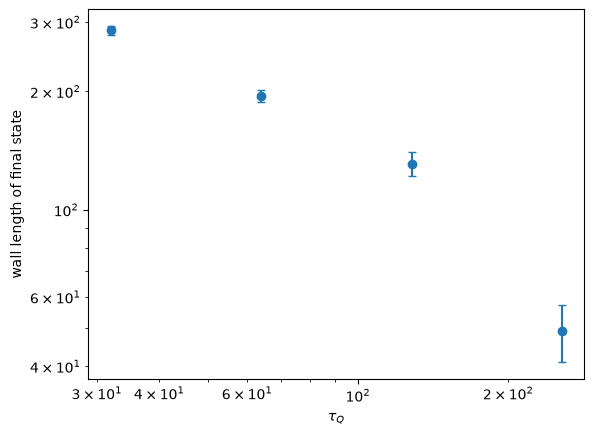

In [2]:
mean, err = [], []

for tau in TAUS:
    d = an.load_chunk(tau)
    w = an.wall_length(d["phi_final"])          # one value per sample
    mean.append(w.mean())
    err.append(w.std() / np.sqrt(len(w)))
    print(f"tau={tau:4d}   wall = {w.mean():6.1f} ± {w.std():5.1f}   (n={len(w)})")

mean, err = np.array(mean), np.array(err)

plt.errorbar(TAUS, mean, yerr=err, fmt="o", capsize=3)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("$\\tau_Q$")
plt.ylabel("wall length of final state")
plt.show()

tau=  32   wall =  285.5 ±  52.8   (n=50)
tau=  64   wall =  195.0 ±  49.5   (n=50)
tau= 128   wall =  130.8 ±  64.1   (n=50)
tau= 256   wall =   49.2 ±  57.9   (n=50)


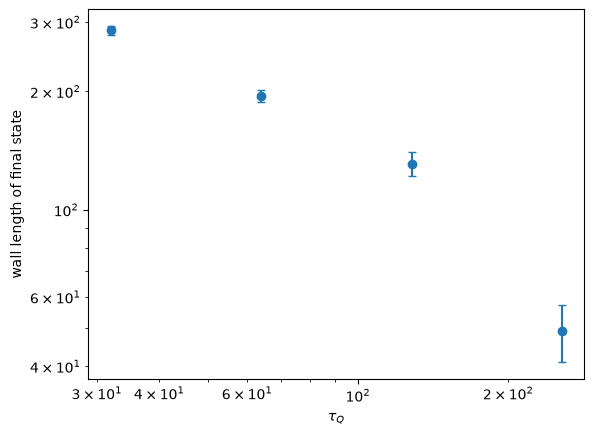

In [3]:
mean, err = [], []

for tau in TAUS:
    d = an.load_chunk(tau)
    w = an.wall_length(d["phi_final"])          # one value per sample
    mean.append(w.mean())
    err.append(w.std() / np.sqrt(len(w)))
    print(f"tau={tau:4d}   wall = {w.mean():6.1f} ± {w.std():5.1f}   (n={len(w)})")

mean, err = np.array(mean), np.array(err)

plt.errorbar(TAUS, mean, yerr=err, fmt="o", capsize=3)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("$\\tau_Q$")
plt.ylabel("wall length of final state")
plt.show()

In [5]:
for tau, m in zip(TAUS, mean):
    xi = 128**2 / m          # area per unit wall = domain size
    print(f"tau={tau:4d}  wall={m:6.1f}  xi={xi:6.1f} sites  domains/side={128/xi:.1f}")

tau=  32  wall= 285.5  xi=  57.4 sites  domains/side=2.2
tau=  64  wall= 195.0  xi=  84.0 sites  domains/side=1.5
tau= 128  wall= 130.8  xi= 125.3 sites  domains/side=1.0
tau= 256  wall=  49.2  xi= 333.1 sites  domains/side=0.4


In [6]:
for tau in [2, 4, 8, 16, 32]:
    d = an.load_chunk(tau)
    w = an.wall_length(d["phi_final"]).mean()
    xi = 128**2 / w
    print(f"tau={tau:4d}  xi={xi:6.1f}  domains/side={128/xi:.1f}")

tau=   2  xi=   3.4  domains/side=37.3
tau=   4  xi=   4.1  domains/side=31.1
tau=   8  xi=   6.4  domains/side=20.1
tau=  16  xi=  19.7  domains/side=6.5
tau=  32  xi=  57.4  domains/side=2.2


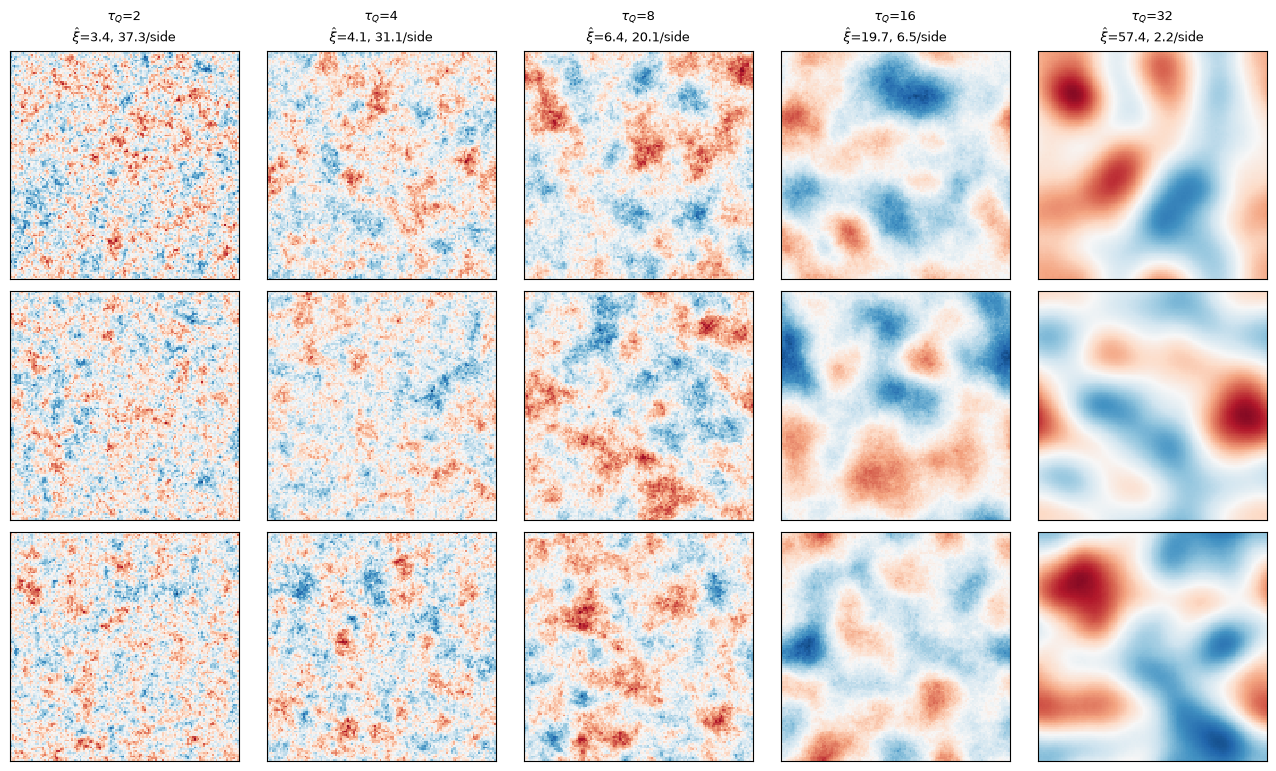

In [8]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
import src.analysis as an

TAUS  = [2, 4, 8, 16, 32]
NSAMP = 3

fig, axes = plt.subplots(NSAMP, len(TAUS), figsize=(2.6*len(TAUS), 2.6*NSAMP),
                         squeeze=False)

for col, tau in enumerate(TAUS):
    d  = an.load_chunk(tau)
    w  = an.wall_length(d["phi_final"])
    xi = 128**2 / w.mean()
    for row in range(NSAMP):
        f = d["phi_final"][row]
        v = 1.1*np.abs(f).max()
        axes[row, col].imshow(f, cmap="RdBu_r", vmin=-v, vmax=v,
                              interpolation="nearest")
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[0, col].set_title(f"$\\tau_Q$={tau}\n$\\hat\\xi$={xi:.1f}, {128/xi:.1f}/side",
                           fontsize=9)

plt.tight_layout()
plt.savefig("../figures/final_states_vs_tau.png", dpi=150)
plt.show()